In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_churn_data.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt


### Customers with month-to-month contracts have higher churn.

### Customers with lower tenure are more likely to churn.

### Customers with higher monthly charges show higher churn risk.

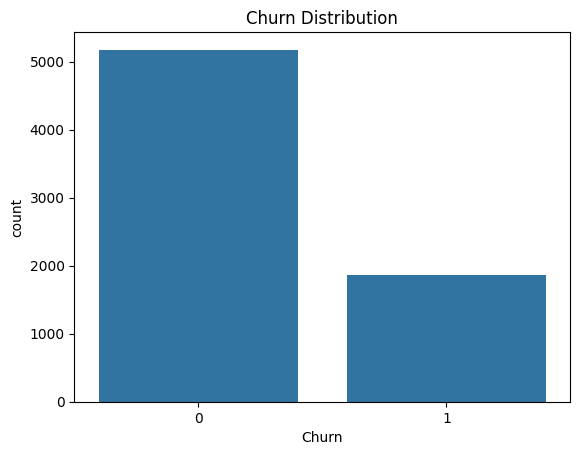

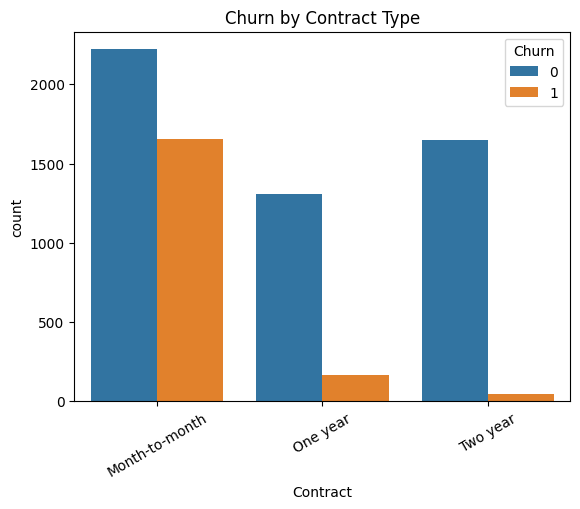

In [6]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xticks(rotation=30)
plt.show()

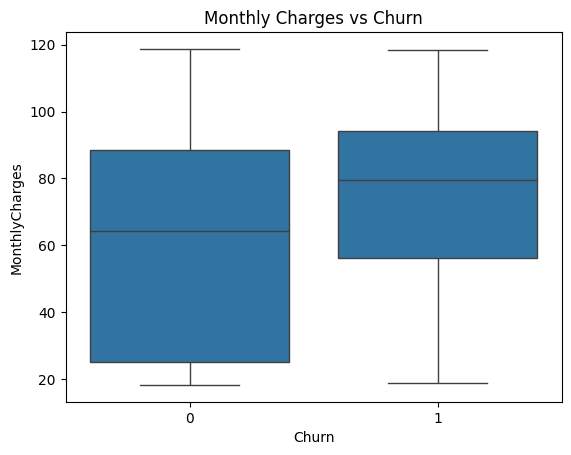

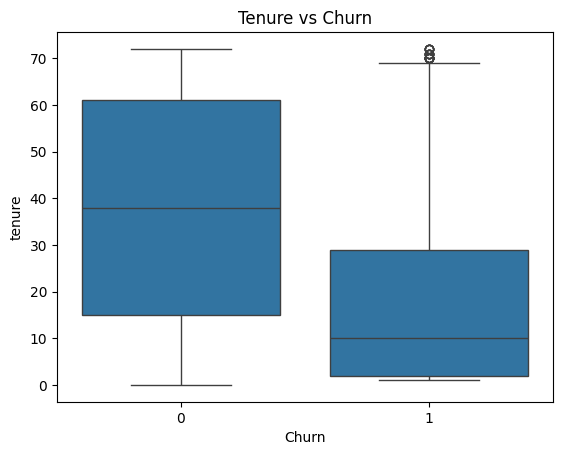

In [5]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.show()

## business insight

In [8]:
# total customers
total_customers = len(df)  
total_customers

7043

In [10]:
# churn rate 
churn_rate = df['Churn'].mean()*100
churn_rate

np.float64(26.536987079369588)

In [17]:
# monthly revenue  
monthly_revenue = df['MonthlyCharges'].sum()
monthly_revenue

np.float64(456116.6)

In [24]:
# revenue lost 
revenue_lost = df[df['Churn']==1]['MonthlyCharges'].sum()
revenue_lost

np.float64(139130.85)

In [25]:
print("Total Customers:", total_customers)
print("Churn Rate:", round(churn_rate, 2))
print("Monthly Revenue:", round(monthly_revenue, 2))
print("Monthly Revenue at Risk:", round(revenue_lost, 2))

Total Customers: 7043
Churn Rate: 26.54
Monthly Revenue: 456116.6
Monthly Revenue at Risk: 139130.85


In [27]:
df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

In [28]:
df.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False)

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: float64

In [29]:
df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False)


InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64